# The HCMST documentation confirms that the data is a wide-format 3-wave panel with wave prefixes w1, w2, and w3_, and that the key weights are w1_weight_combo, w2_attrition_adj_weights, and w3_attrition_adj_weight. It also confirms the sample sizes of 3510 in wave 1, 2107 in wave 2, and 1722 in wave 3.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path
import missingno as msno 

In [2]:
PROJECT_ROOT = Path("..")
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DARA_PROCESSED = PROJECT_ROOT / "data" / "processed"

OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUTS_FIGURES = OUTPUTS / "figures"
OUTPUTS_SLIDES = OUTPUTS / "slides"
OUTPUT_TABLES =  OUTPUTS / "tables"

In [3]:
df = pd.read_spss("/home/becode/Desktop/BeCode/becode_projects/hcmst_project/data/raw/HCMST 2017 to 2022 small public version 2.2.sav")

# first looks at the dataset 

In [4]:
df.head()

,caseid_new,w3_Weight,w3_Weight_LGB,w3_combo_weight,w3_attrition_adj_weight,w2_weight_genpop,w2_weight_LGB,w2_combo_weight,w2_attrition_adj_weights,w1_weight_combo,...,p20_pppa1634,p20_pppa1902,p20_pppa1903,p20_pppa1904,p20_ppp22001,p20_pppa1905,p20_pppa1648,p20_ppp20072,p20_ppp20071,p20_ppp2date2020
0,53001.0,0.4422,NaN,0.495308,0.400185,0.3856,NaN,0.437670,0.380351,0.426861,...,Female,No,Female,No,No,No,No religion,Never,NaN,20210506.0
1,71609.0,0.8284,NaN,0.927891,0.879258,0.9196,NaN,1.043778,0.953948,1.295508,...,Female,No,Female,No,No,No,"Evangelical or Protestant Christian (Baptist, ...",Once a year or less,Yes,20201118.0
2,106983.0,0.8255,NaN,0.924643,0.706467,0.7748,NaN,0.879425,0.724682,1.126573,...,Male,Male,No,No,No,No,Catholic,A few times a year,No,20210429.0
3,121759.0,NaN,NaN,NaN,NaN,0.9177,NaN,1.041622,0.793093,0.933440,...,Male,Male,No,No,No,No,Other Christian religion,Once a week,Yes,20210507.0
4,158083.0,0.8810,NaN,0.986809,0.655467,0.8697,NaN,0.987140,0.735473,0.931291,...,Male,Male,No,No,No,No,No religion,Never,NaN,20210602.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3510 entries, 0 to 3509
Columns: 725 entries, caseid_new to p20_ppp2date2020
dtypes: category(586), float64(139)
memory usage: 5.7 MB


In [6]:
df.describe()

,caseid_new,w3_Weight,w3_Weight_LGB,w3_combo_weight,w3_attrition_adj_weight,w2_weight_genpop,w2_weight_LGB,w2_combo_weight,w2_attrition_adj_weights,w1_weight_combo,...,p18_ppfsdate2018,p19_ppcmdate2019,p19_pppadate2019,p19_ppfsdate2019,p19_ppsidate2019,p20_ppcmdate2020,p20_ppfsdate2020,p20_ppsidate2020,p20_ppp1date2020,p20_ppp2date2020
count,3.510000e+03,1539.000000,249.000000,1722.000000,1722.000000,1866.000000,324.000000,2107.000000,2107.000000,3510.000000,...,2.479000e+03,2.527000e+03,2.232000e+03,2.026000e+03,2.445000e+03,2.144000e+03,1.513000e+03,2.145000e+03,2.261000e+03,1.664000e+03
mean,2.181073e+06,1.000000,1.000002,1.000000,1.000000,0.999999,1.000000,1.000004,1.000000,1.000000,...,2.019044e+07,2.019272e+07,2.019947e+07,2.020039e+07,2.019106e+07,2.020772e+07,2.020973e+07,2.020261e+07,2.020176e+07,2.020827e+07
std,6.401295e+05,0.633241,1.148453,0.718274,1.052068,0.544041,1.069949,0.659577,0.850085,0.437515,...,2.132721e+02,3.495848e+03,3.124271e+03,5.916359e+02,1.698214e+03,4.042153e+03,2.244402e+03,3.393332e+03,2.550661e+03,4.018957e+03
min,5.300100e+04,0.282500,0.118700,0.041785,0.026903,0.211500,0.104900,0.033166,0.024435,0.058970,...,2.019012e+07,2.019051e+07,2.019082e+07,2.019112e+07,2.019062e+07,2.020090e+07,2.020111e+07,2.020101e+07,2.020091e+07,2.020092e+07
25%,1.825512e+06,0.591000,0.270300,0.570243,0.444287,0.641225,0.357925,0.602817,0.505188,0.818612,...,2.019030e+07,2.019110e+07,2.020052e+07,2.020022e+07,2.019072e+07,2.020122e+07,2.021022e+07,2.020110e+07,2.020092e+07,2.021018e+07
50%,2.282692e+06,0.816000,0.594900,0.833131,0.704241,0.856350,0.649350,0.865124,0.754859,1.012706,...,2.019032e+07,2.019112e+07,2.020060e+07,2.020031e+07,2.019072e+07,2.021020e+07,2.021031e+07,2.020112e+07,2.020093e+07,2.021051e+07
75%,2.759544e+06,1.184900,1.333500,1.211305,1.167013,1.212500,1.257600,1.255406,1.233717,1.245077,...,2.019062e+07,2.019121e+07,2.020071e+07,2.020060e+07,2.019080e+07,2.021022e+07,2.021033e+07,2.020121e+07,2.020112e+07,2.021060e+07
max,2.972135e+06,4.172300,6.195200,4.673395,14.638303,4.030000,6.209200,4.574192,7.077054,3.110826,...,2.019111e+07,2.020080e+07,2.020090e+07,2.020103e+07,2.020100e+07,2.021060e+07,2.021061e+07,2.021061e+07,2.021061e+07,2.021061e+07


In [7]:
df.describe(include= "category")

,w3_xpartner_type,w3_xcohab,w3_xsamesex,w3_gen_pop_sample,w3_ppagecat,w3_ppagect4,w3_ppeduc,w3_ppeducat,w3_ppethm,w3_ppgender,...,p20_pppagnid,p20_pppa1634,p20_pppa1902,p20_pppa1903,p20_pppa1904,p20_ppp22001,p20_pppa1905,p20_pppa1648,p20_ppp20072,p20_ppp20071
count,3510,2795,2995,1722,1722,1722,1722,1722,1722,1722,...,1653,1656,1657,1657,1657,1657,1657,1656,1654,1152
unique,4,2,2,2,7,4,14,4,5,2,...,4,2,2,2,2,2,2,13,6,2
top,married,yes,Not same sex couple,general population sample (includes some LGB),55-64,60+,HIGH SCHOOL GRADUATE - high school DIPLOMA or ...,Bachelor's degree or higher,"White, Non-Hispanic",Male,...,Cisgender,Male,Male,No,No,No,No,"Evangelical or Protestant Christian (Baptist, ...",Never,No
freq,2076,2414,2759,1539,423,787,411,742,1300,949,...,1638,900,899,906,1655,1650,1654,600,582,735


In [8]:
df.columns[:30]

Index(['caseid_new', 'w3_Weight', 'w3_Weight_LGB', 'w3_combo_weight',
       'w3_attrition_adj_weight', 'w2_weight_genpop', 'w2_weight_LGB',
       'w2_combo_weight', 'w2_attrition_adj_weights', 'w1_weight_combo',
       'w1_weight_combo_freqwt', 'w3_xpartner_type', 'w3_xlast_contact_year',
       'w3_xcohab', 'w3_xsamesex', 'w3_xlast_contact_mo', 'w3_xnamep_present',
       'w3_duration', 'w3_gen_pop_sample', 'w3_ppage', 'w3_ppagecat',
       'w3_ppagect4', 'w3_ppeduc', 'w3_ppeducat', 'w3_ppethm', 'w3_ppgender',
       'w3_pphhhead', 'w3_pphhsize', 'w3_pphouse', 'w3_ppincimp'],
      dtype='str')

In [9]:
df.sample(5, random_state=42)

,caseid_new,w3_Weight,w3_Weight_LGB,w3_combo_weight,w3_attrition_adj_weight,w2_weight_genpop,w2_weight_LGB,w2_combo_weight,w2_attrition_adj_weights,w1_weight_combo,...,p20_pppa1634,p20_pppa1902,p20_pppa1903,p20_pppa1904,p20_ppp22001,p20_pppa1905,p20_pppa1648,p20_ppp20072,p20_ppp20071,p20_ppp2date2020
3192,2914149.0,1.4256,NaN,1.596815,1.556315,1.5786,NaN,1.791767,1.903209,1.426563,...,Male,Male,No,No,No,No,Catholic,A few times a year,No,20210605.0
315,1158149.0,NaN,NaN,NaN,NaN,1.1146,NaN,1.265110,1.052066,1.124651,...,Female,No,Female,No,No,No,Catholic,A few times a year,No,20210605.0
2668,2772025.0,1.9336,0.81,0.680668,0.625724,1.7812,1.0285,0.563155,0.515837,0.622396,...,Male,Male,No,No,No,No,No religion,Never,NaN,20210506.0
599,1558639.0,0.3633,NaN,0.406933,0.363693,0.5031,NaN,0.571036,0.482126,0.772872,...,Female,No,Female,No,No,No,Other Christian religion,Never,No,20201222.0
874,1823725.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.138424,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.isna().sum()


caseid_new                    0
w3_Weight                  1971
w3_Weight_LGB              3261
w3_combo_weight            1788
w3_attrition_adj_weight    1788
                           ... 
p20_pppa1905               1853
p20_pppa1648               1854
p20_ppp20072               1856
p20_ppp20071               2358
p20_ppp2date2020           1846
Length: 725, dtype: int64

In [11]:
df.shape

(3510, 725)

# Confimrming the dataset structure by wave

In [12]:
w1_cols = [col for col in df.columns if col.startswith("w1_")]
w2_cols = [col for col in df.columns if col.startswith("w2_")]
w3_cols = [col for col in df.columns if col.startswith("w3_")]


print ("Wave 1 columns:", len(w1_cols))
print ("Wave 2 columns:", len(w2_cols))
print ("Wave 3 columns:", len(w3_cols))

Wave 1 columns: 199
Wave 2 columns: 193
Wave 3 columns: 191


In [13]:
print ("sample w1 columns:", w1_cols[:50])
print ("sample w2 columns:", w2_cols[:50])
print ("sample w3 columns:", w3_cols[:50])

sample w1 columns: ['w1_weight_combo', 'w1_weight_combo_freqwt', 'w1_duration', 'w1_speed_flag', 'w1_consent', 'w1_partyid7', 'w1_PERSNET_hom', 'w1_ppc10017', 'w1_ppc21310', 'w1_ppp20071', 'w1_ppp20072', 'w1_ppage', 'w1_ppagecat', 'w1_ppagect4', 'w1_ppeduc', 'w1_ppeducat', 'w1_ppethm', 'w1_ppRace_1', 'w1_ppRace_2', 'w1_ppRace_3', 'w1_ppRace_4', 'w1_ppRace_5', 'w1_ppRace_6', 'w1_pprace1', 'w1_pprace2', 'w1_pprace3', 'w1_pprace4', 'w1_pprace5', 'w1_pprace6', 'w1_pprace7', 'w1_pprace8', 'w1_pprace9', 'w1_pprace10', 'w1_pprace11', 'w1_pprace12', 'w1_pprace13', 'w1_pprace14', 'w1_pprace15', 'w1_ppgender', 'w1_pphhhead', 'w1_pphhsize', 'w1_pphouse', 'w1_ppincimp', 'w1_ppincimp_cat', 'w1_ppmarit', 'w1_ppmsacat', 'w1_PPREG4', 'w1_ppreg9', 'w1_pprent', 'w1_PPT01']
sample w2 columns: ['w2_weight_genpop', 'w2_weight_LGB', 'w2_combo_weight', 'w2_attrition_adj_weights', 'w2_month_of_survey', 'w2_xpartner_type', 'w2_xcohab', 'w2_xpppa_lgb_num', 'w2_lgb', 'w2_duration', 'w2_ppage', 'w2_ppagecat', 'w2

### Identifying the key survey participants variables

In [14]:
key_cols = [
    "caseid_new",
    "w1_weight_combo",
    "w2_attrition_adj_weights",
    "w3_attrition_adj_weight",
    "w2_surveyed",
    "w3_surveyed"
]
df[key_cols].head()

,caseid_new,w1_weight_combo,w2_attrition_adj_weights,w3_attrition_adj_weight,w2_surveyed,w3_surveyed
0,53001.0,0.426861,0.380351,0.400185,yes,yes
1,71609.0,1.295508,0.953948,0.879258,yes,yes
2,106983.0,1.126573,0.724682,0.706467,yes,yes
3,121759.0,0.933440,0.793093,NaN,yes,no
4,158083.0,0.931291,0.735473,0.655467,yes,yes


In [15]:
df[key_cols].describe(include="all")

,caseid_new,w1_weight_combo,w2_attrition_adj_weights,w3_attrition_adj_weight,w2_surveyed,w3_surveyed
count,3.510000e+03,3510.000000,2107.000000,1722.000000,3510,3510
unique,NaN,NaN,NaN,NaN,2,2
top,NaN,NaN,NaN,NaN,yes,no
freq,NaN,NaN,NaN,NaN,2107,1788
mean,2.181073e+06,1.000000,1.000000,1.000000,NaN,NaN
std,6.401295e+05,0.437515,0.850085,1.052068,NaN,NaN
min,5.300100e+04,0.058970,0.024435,0.026903,NaN,NaN
25%,1.825512e+06,0.818612,0.505188,0.444287,NaN,NaN
50%,2.282692e+06,1.012706,0.754859,0.704241,NaN,NaN
75%,2.759544e+06,1.245077,1.233717,1.167013,NaN,NaN


In [16]:
print("Total respondents (merged rows):", len(df))

print("\nWave 2 participation:")
print(df["w2_surveyed"].value_counts(dropna=False))

print("\nWave 3 participation:")
print(df["w3_surveyed"].value_counts(dropna=False))

Total respondents (merged rows): 3510

Wave 2 participation:
w2_surveyed
yes    2107
no     1403
Name: count, dtype: int64

Wave 3 participation:
w3_surveyed
no     1788
yes    1722
Name: count, dtype: int64


In [17]:
df["w2_surveyed"].unique()
df["w3_surveyed"].unique()

['yes', 'no']
Categories (2, str): ['no', 'yes']

## Dataset confirmation
#### According to the documentation: The merged file contains 3150 rows , corresponding to the full original wave 1 sample. 
##### Wave 1 sample size = 3510 
##### Wave 2 sample size = 2107 (w2_surveyed == "yes")
##### Wave 3 sample size = 1722 (w3_surveyed == "yes")
##### Wave 1 analytic weight = w1_weight_combo
##### Wave 2 attrition-adjusted weight = w2_attrition_adj_weights
##### Wave 3 attrition-adjusted weight = w3_attrition_adj_weight

### The dataset is a wide-format panel, with one row per respondent and wave-specific prefixes:
## w1_ for 2017
## w2_ for 2020
## w3_ for 2022

In [18]:
candidate_vars = [
    # identifiers and weights
    "caseid_new",
    "w1_weight_combo",
    "w2_attrition_adj_weights",
    "w3_attrition_adj_weight",
    "w2_surveyed",
    "w3_surveyed",

    # wave 1 demographics
    "w1_ppage",
    "w1_ppeduc",
    "w1_ppincimp",
    "w1_ppgender",
    "w1_ppethm",
    "w1_ppreg9",

    # wave 1 relationship structure
    "w1_partnership_status",
    "w1_q19",
    "w1_married",
    "w1_same_sex_couple",
    "w1_relate_duration_in2017_years",
    "w1_q34",

    # how couples met
    "w1_q24_met_online",
    "w1_q24_met_through_friend",
    "w1_q24_met_through_family",
    "w1_q24_met_as_through_cowork",
    "w1_q24_school",
    "w1_q24_college",
    "w1_q24_church",
    "w1_q24_bar_restaurant",
    "w1_q24_party",
    "w1_q32",

    # wave 3 outcome candidates
    "w3_partner_type",
    "w3_married",
    "w3_live_w_partner",
    "w3_relationship_end_combo",
    "w3_partner_source",
    "w3_breakup_source",
    "w3_relationship_duration_yrs"
]

existing_candidate_vars = [c for c in candidate_vars if c in df.columns]
missing_candidate_vars = [c for c in candidate_vars if c not in df.columns]

print("Existing candidate vars:", len(existing_candidate_vars))
print("Missing candidate vars:", missing_candidate_vars)

Existing candidate vars: 35
Missing candidate vars: []


In [19]:
df[existing_candidate_vars].head()

,caseid_new,w1_weight_combo,w2_attrition_adj_weights,w3_attrition_adj_weight,w2_surveyed,w3_surveyed,w1_ppage,w1_ppeduc,w1_ppincimp,w1_ppgender,...,w1_q24_bar_restaurant,w1_q24_party,w1_q32,w3_partner_type,w3_married,w3_live_w_partner,w3_relationship_end_combo,w3_partner_source,w3_breakup_source,w3_relationship_duration_yrs
0,53001.0,0.426861,0.380351,0.400185,yes,yes,48.0,HIGH SCHOOL GRADUATE - high school DIPLOMA or ...,"$60,000 to $74,999",Female,...,yes,no,"No, I did NOT meet [Partner Name] through the ...",in unmarried partnership,no,yes,no report of breakup or partner death,2020 wave,NaN,1.500000
1,71609.0,1.295508,0.953948,0.879258,yes,yes,68.0,"Some college, no degree","$50,000 to $59,999",Female,...,no,yes,"No, I did NOT meet [Partner Name] through the ...",married,yes,yes,no report of breakup or partner death,2017 wave,NaN,57.416668
2,106983.0,1.126573,0.724682,0.706467,yes,yes,39.0,Associate degree,"$85,000 to $99,999",Male,...,no,no,"No, I did NOT meet [Partner Name] through the ...",married,yes,yes,no report of breakup or partner death,2017 wave,NaN,22.333334
3,121759.0,0.933440,0.793093,NaN,yes,no,54.0,HIGH SCHOOL GRADUATE - high school DIPLOMA or ...,"$100,000 to $124,999",Male,...,no,no,"No, I did NOT meet [Partner Name] through the ...",not in wave 3,NaN,NaN,NaN,NaN,NaN,NaN
4,158083.0,0.931291,0.735473,0.655467,yes,yes,48.0,"Some college, no degree","$75,000 to $84,999",Male,...,no,no,"No, I did NOT meet [Partner Name] through the ...",unpartnered,no,NaN,no report of breakup or partner death,NaN,NaN,NaN


In [20]:
candidate_nonmissing = df[existing_candidate_vars].notna().sum().sort_values(ascending=False)
candidate_nonmissing

caseid_new                         3510
w1_weight_combo                    3510
w2_surveyed                        3510
w1_partnership_status              3510
w3_surveyed                        3510
w1_ppage                           3510
w1_ppeduc                          3510
w1_ppgender                        3510
w1_ppincimp                        3510
w1_ppethm                          3510
w1_ppreg9                          3510
w3_partner_type                    3510
w1_q32                             3394
w1_married                         3394
w1_q24_met_online                  3394
w1_same_sex_couple                 3394
w1_q24_party                       3295
w1_q24_met_through_family          3295
w1_q24_met_through_friend          3295
w1_q24_college                     3295
w1_q24_bar_restaurant              3295
w1_q24_met_as_through_cowork       3295
w1_q24_school                      3295
w1_q24_church                      3295
w1_q19                             2852


In [21]:
candidate_missing_pct = df[existing_candidate_vars].isna().mean().sort_values(ascending=False) * 100
candidate_missing_pct

w3_breakup_source                  96.894587
w3_relationship_duration_yrs       62.991453
w3_live_w_partner                  61.908832
w3_partner_source                  61.908832
w3_attrition_adj_weight            50.940171
w3_married                         50.940171
w3_relationship_end_combo          50.940171
w2_attrition_adj_weights           39.971510
w1_relate_duration_in2017_years    21.225071
w1_q34                             18.888889
w1_q19                             18.746439
w1_q24_school                       6.125356
w1_q24_met_as_through_cowork        6.125356
w1_q24_met_through_family           6.125356
w1_q24_met_through_friend           6.125356
w1_q24_college                      6.125356
w1_q24_church                       6.125356
w1_q24_bar_restaurant               6.125356
w1_q24_party                        6.125356
w1_q32                              3.304843
w1_q24_met_online                   3.304843
w1_same_sex_couple                  3.304843
w1_married

In [22]:
variable_dictionary = pd.DataFrame({
    "variable": existing_candidate_vars,
    "missing_pct": df[existing_candidate_vars].isna().mean().round(4) * 100
})

variable_dictionary.to_csv(OUTPUT_TABLES / "initial_variable_dictionary.csv", index=False)
variable_dictionary

,variable,missing_pct
caseid_new,caseid_new,0.00
w1_weight_combo,w1_weight_combo,0.00
w2_attrition_adj_weights,w2_attrition_adj_weights,39.97
w3_attrition_adj_weight,w3_attrition_adj_weight,50.94
w2_surveyed,w2_surveyed,0.00
w3_surveyed,w3_surveyed,0.00
w1_ppage,w1_ppage,0.00
w1_ppeduc,w1_ppeduc,0.00
w1_ppincimp,w1_ppincimp,0.00
w1_ppgender,w1_ppgender,0.00


# Partnership Status 

In [23]:
df["w1_partnership_status"].value_counts(dropna=False)

w1_partnership_status
married                              2085
partnered, not married                777
unpartnered, has had past partner     541
never had a partner                   107
Name: count, dtype: int64

# Married ?

In [24]:
df["w1_married"].value_counts(dropna=False)

w1_married
yes    2079
no     1315
NaN     116
Name: count, dtype: int64

# cohabiting with partner ? 

In [25]:
df["w1_q19"].value_counts(dropna=False)

w1_q19
Yes    2387
NaN     658
No      465
Name: count, dtype: int64

# same sex couple ?

In [26]:
df["w1_same_sex_couple"].value_counts(dropna=False)

w1_same_sex_couple
NOT same-sex souple    3086
same_sex_couple         308
NaN                     116
Name: count, dtype: int64

# relationship quality 

In [27]:
df["w1_q34"].value_counts(dropna=False)

w1_q34
Excellent    1706
Good          884
NaN           663
Fair          202
Poor           32
Very Poor      23
Name: count, dtype: int64

# met online

In [28]:
df["w1_q24_met_online"].value_counts(dropna=False)

w1_q24_met_online
no     2992
yes     402
NaN     116
Name: count, dtype: int64

# age

In [29]:
df["w1_ppage"].value_counts(dropna=False)

w1_ppage
27.0    97
28.0    92
58.0    89
55.0    85
54.0    83
        ..
89.0     2
91.0     2
93.0     2
88.0     1
92.0     1
Name: count, Length: 76, dtype: int64

# Partner Type 

In [30]:
df["w3_partner_type"].value_counts(dropna=False)

w3_partner_type
not in wave 3               1788
married                     1061
unpartnered                  385
in unmarried partnership     276
Name: count, dtype: int64

# how relationships ended

In [31]:
df["w3_relationship_end_combo"].value_counts(dropna=False)

w3_relationship_end_combo
NaN                                      1788
no report of breakup or partner death    1623
Separated/ Broke up                        62
Partner died                               27
Got Divorced                               10
Name: count, dtype: int64

# Gender 

In [32]:
df["w1_ppgender"].value_counts(dropna=False)

w1_ppgender
Female    1764
Male      1746
Name: count, dtype: int64

# Race and ethnicity 

In [33]:
df["w1_ppethm"].value_counts(dropna=False)

w1_ppethm
White, Non-Hispanic       2503
Hispanic                   438
Black, Non-Hispanic        311
Other, Non-Hispanic        147
2+ Races, Non-Hispanic     111
Name: count, dtype: int64

# Employement status

In [34]:
df["w1_ppwork"].value_counts(dropna=False)

w1_ppwork
Working - as a paid employee                    1968
Not working - retired                            663
Working - self-employed                          278
Not working - other                              228
Not working - disabled                           184
Not working - looking for work                   178
Not working - on temporary layoff from a job      11
Name: count, dtype: int64

In [36]:
df["w1_q32"].value_counts(dropna=False)

w1_q32
No, I did NOT meet [Partner Name] through the Internet                      2920
Yes, an Internet dating or matchmaking site (like eHarmony or match.com)     191
NaN                                                                          116
Yes, a social networking site (like Facebook or Myspace)                      86
Yes, an app on my phone (like Tinder or Grindr)                               70
Yes, a different kind of Internet service                                     48
Yes, an Internet chat room                                                    46
Yes, an Internet classified advertising site (like Craigslist)                20
Refused                                                                       13
Name: count, dtype: int64

## Initial interpretation of key variables

### Wave 1 relationship profile (2017)

- `w1_partnership_status`: respondent’s relationship status in Wave 1.  
  Categories observed:
  - married (2085)
  - partnered, not married (777)
  - unpartnered, has had past partner (541)
  - never had a partner (107)

  This is the main variable to identify who belongs in the active-relationship sample for clustering.

---

- `w1_married`: whether the respondent was married in 2017.  
  Categories observed:
  - yes (2079)
  - no (1315)
  - missing (116)

  Useful as a commitment / relationship stability indicator.

---

- `w1_q19`: whether the respondent was cohabiting / living with a partner in Wave 1.  
  Categories observed:
  - Yes (2387)
  - No (465)
  - missing (658)

  Indicates household integration and relationship seriousness.

---

- `w1_same_sex_couple`: whether the relationship is a same-sex couple.  
  Categories observed:
  - NOT same-sex couple (3086)
  - same_sex_couple (308)
  - missing (116)

  Important because the dataset intentionally oversampled LGB respondents, so weights matter.

---

- `w1_q34`: self-reported relationship quality in Wave 1.  
  Categories observed:
  - Excellent (1706)
  - Good (884)
  - Fair (202)
  - Poor (32)
  - Very Poor (23)
  - missing (663)

  This is a key baseline relationship-strength variable.

---

- `w1_q24_met_online`: whether the respondent met their partner online.  
  Categories observed:
  - no (2992)
  - yes (402)
  - missing (116)

  Main variable for the research question on whether meeting online predicts later outcomes.

---

### Wave 1 demographics

- `w1_ppage`: respondent age in 2017.  
  Numeric continuous variable with broad adult age distribution.

---

- `w1_ppgender`: respondent gender.  
  Categories observed:
  - Female (1764)
  - Male (1746)

---

- `w1_ppethm`: respondent race / ethnicity.  
  Main categories observed:
  - White, Non-Hispanic (2503)
  - Hispanic (438)
  - Black, Non-Hispanic (311)
  - Other, Non-Hispanic (147)
  - 2+ Races, Non-Hispanic (111)

---

- `w1_ppwork`: employment status in Wave 1.  
  Categories include:
  - Working as paid employee
  - Working self-employed
  - Retired
  - Disabled
  - Looking for work
  - Other not working

  Useful socioeconomic control variable.

---

### Wave 3 outcomes (2022)

- `w3_partner_type`: relationship status in Wave 3.  
  Categories observed:
  - not in wave 3 (1788)
  - married (1061)
  - unpartnered (385)
  - in unmarried partnership (276)

  Useful for describing later relationship outcomes.

---

- `w3_relationship_end_combo`: whether the prior relationship ended by Wave 3.  
  Categories observed:
  - no report of breakup or partner death (1623)
  - Separated / Broke up (62)
  - Partner died (27)
  - Got divorced (10)
  - missing / not in wave 3 (1788)

  Candidate variable for constructing the “still together in 2022” outcome.

---

## Initial analytical conclusions

1. Most respondents were partnered in Wave 1, with marriage being the largest category.
2. Most respondents report high relationship quality (“Excellent” or “Good”).
3. Meeting online is present but still a minority pathway in this sample.
4. There is substantial attrition by Wave 3 (1788 not reinterviewed).
5. Wave 1 partnered respondents are the appropriate starting sample for clustering.
6. Wave 3 variables can be used to study long-term relationship survival.

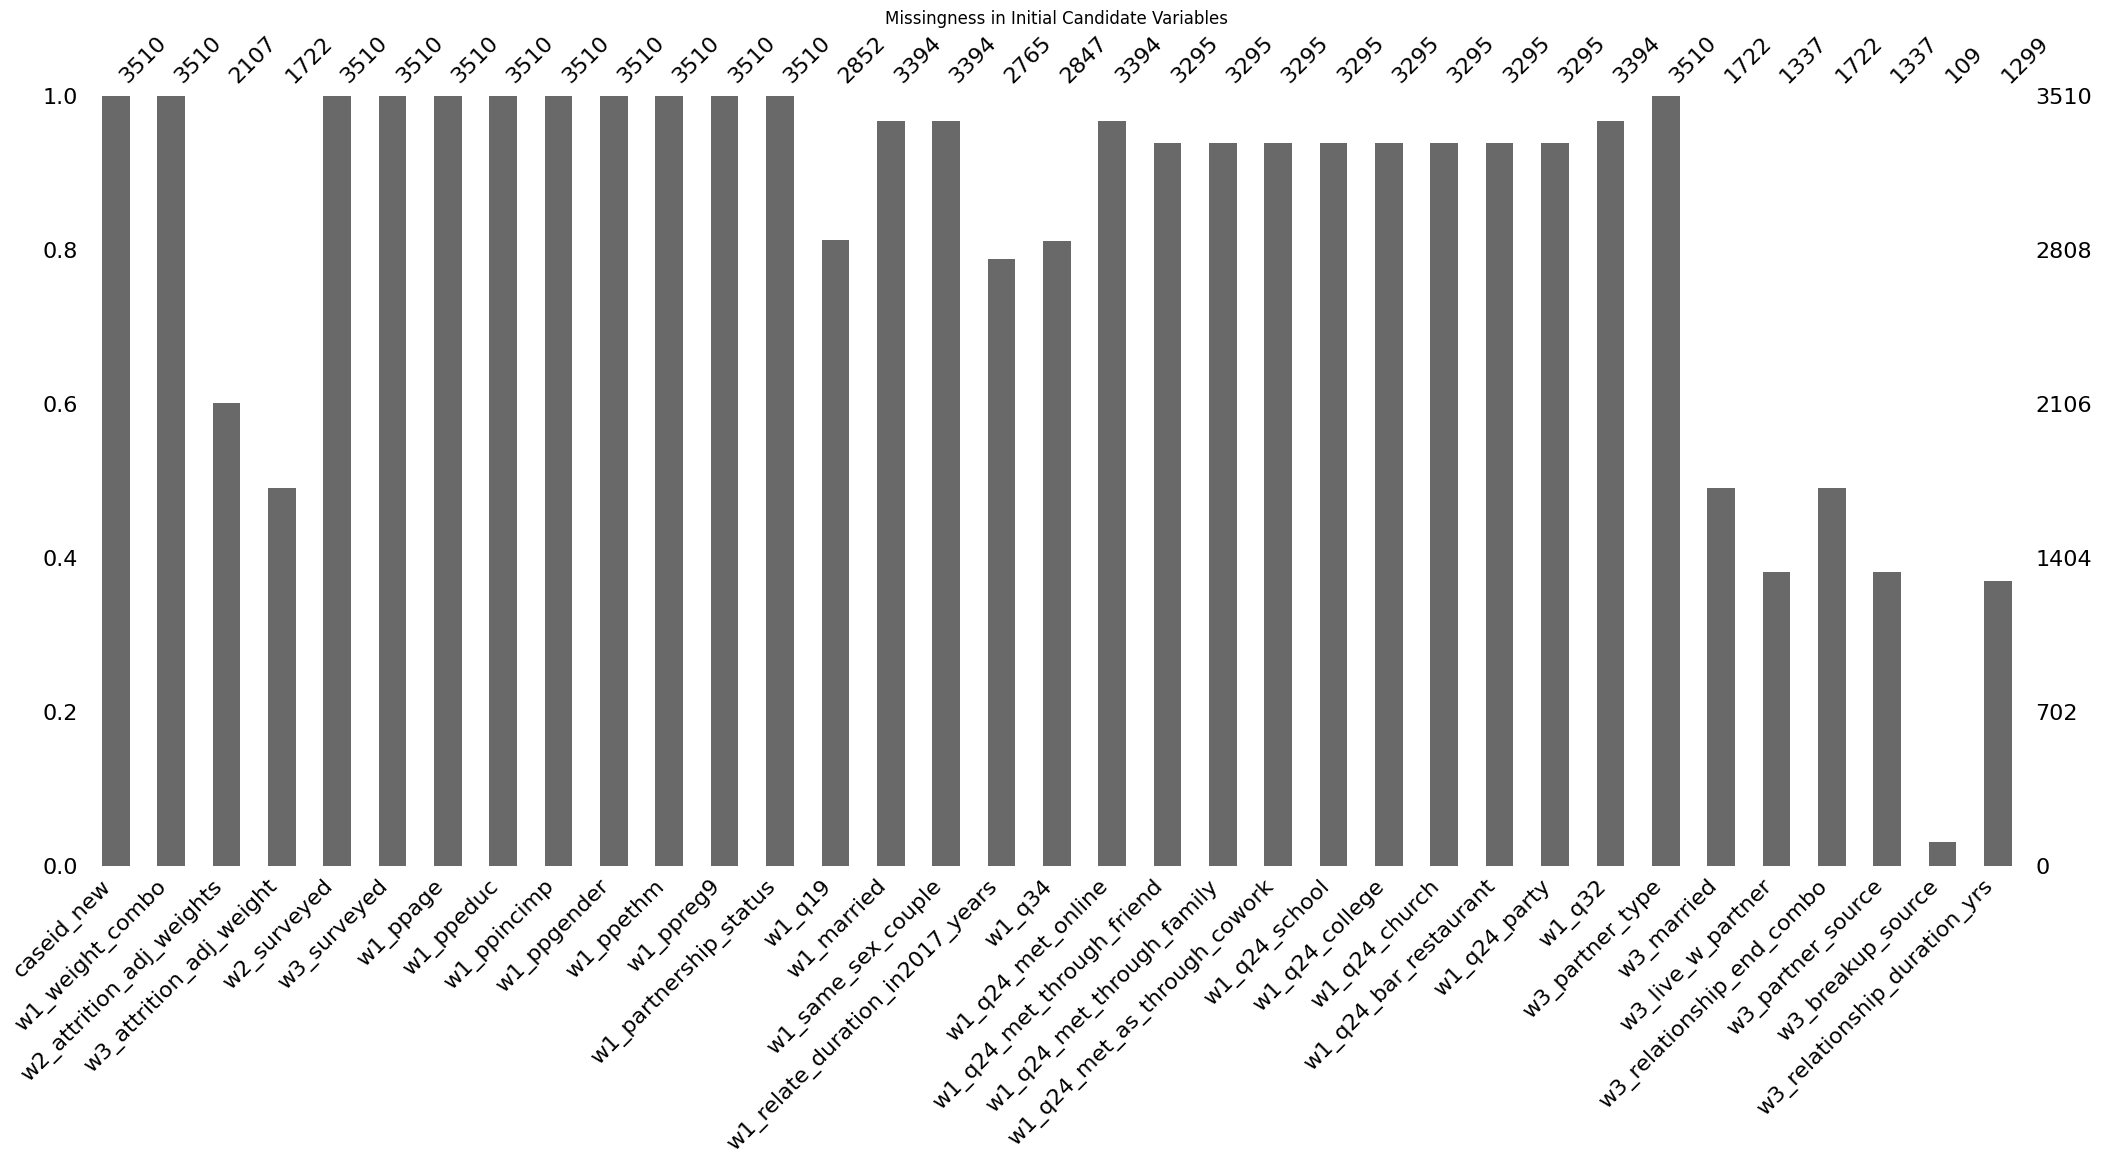

In [35]:
plt.figure(figsize=(12,6))
msno.bar(df[existing_candidate_vars])
plt.title("Missingness in Initial Candidate Variables")
plt.show()

# Aggregated Exploratory Summaries

The previous sections inspected important variables individually.

The following sections summarize the main variable families in a cleaner way:

1. Demographics (Wave 1 respondent profile)
2. Relationship structure (Wave 1 baseline relationship context)
3. How couples met (Wave 1 `w1_q24_*` family)
4. Wave 3 outcome candidates (2022 relationship outcomes)

These summaries are intended to support later data cleaning, clustering, and modeling.

In [42]:

PALETTE = "steelblue"

def safe_numeric(series):
    return pd.to_numeric(series.astype(str), errors="coerce")

## A. Aggregated Demographics (Wave 1)

This section summarizes the main baseline respondent characteristics in 2017.

Included:
- age
- gender
- race / ethnicity
- education
- income
- employment
- region

In [43]:
age_num = safe_numeric(df["w1_ppage"])

demographics_summary = pd.DataFrame({
    "metric": [
        "sample_size",
        "mean_age",
        "median_age",
        "min_age",
        "max_age",
        "n_gender_categories",
        "n_race_categories",
        "n_education_categories",
        "n_income_categories",
        "n_employment_categories",
        "n_region_categories"
    ],
    "value": [
        len(df),
        round(age_num.mean(), 2),
        round(age_num.median(), 2),
        round(age_num.min(), 2),
        round(age_num.max(), 2),
        df["w1_ppgender"].astype(str).nunique(),
        df["w1_ppethm"].astype(str).nunique(),
        df["w1_ppeduc"].astype(str).nunique(),
        df["w1_ppincimp"].astype(str).nunique(),
        df["w1_ppwork"].astype(str).nunique(),
        df["w1_ppreg9"].astype(str).nunique()
    ]
})

demographics_summary

,metric,value
0,sample_size,3510.00
1,mean_age,48.79
2,median_age,50.00
3,min_age,18.00
4,max_age,93.00
5,n_gender_categories,2.00
6,n_race_categories,5.00
7,n_education_categories,14.00
8,n_income_categories,21.00
9,n_employment_categories,7.00


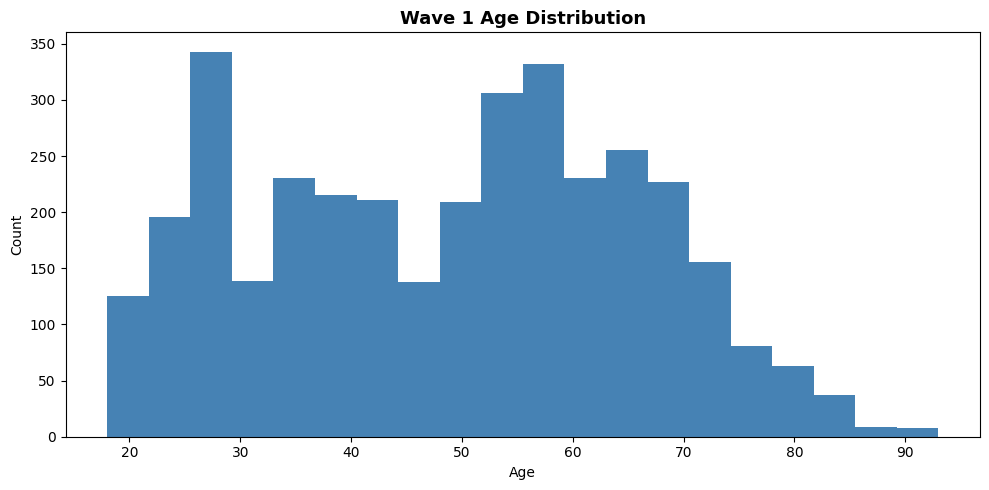

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
age_num.dropna().plot.hist(bins=20, ax=ax, color=PALETTE)

ax.set_title("Wave 1 Age Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

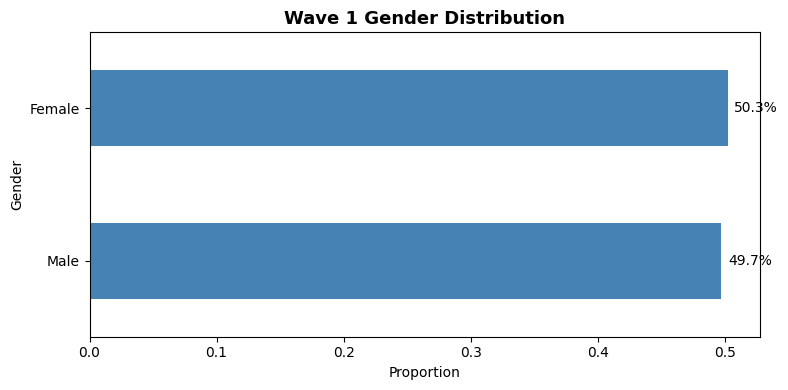

In [45]:
gender_dist = df["w1_ppgender"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
gender_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 1 Gender Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Gender")

for i, val in enumerate(gender_dist.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center")

plt.tight_layout()
plt.show()

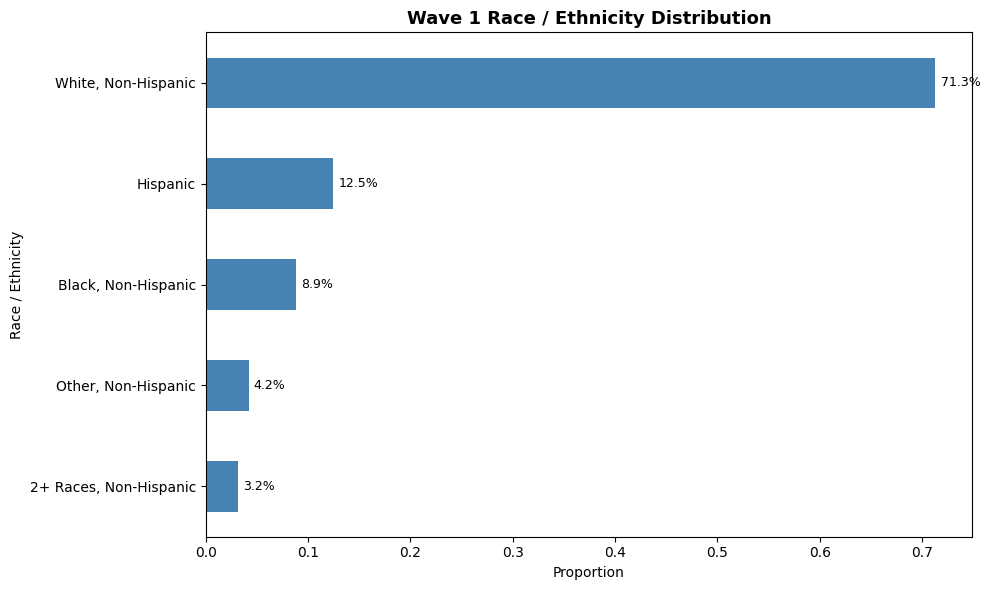

In [46]:
race_dist = df["w1_ppethm"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
race_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 1 Race / Ethnicity Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Race / Ethnicity")

for i, val in enumerate(race_dist.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

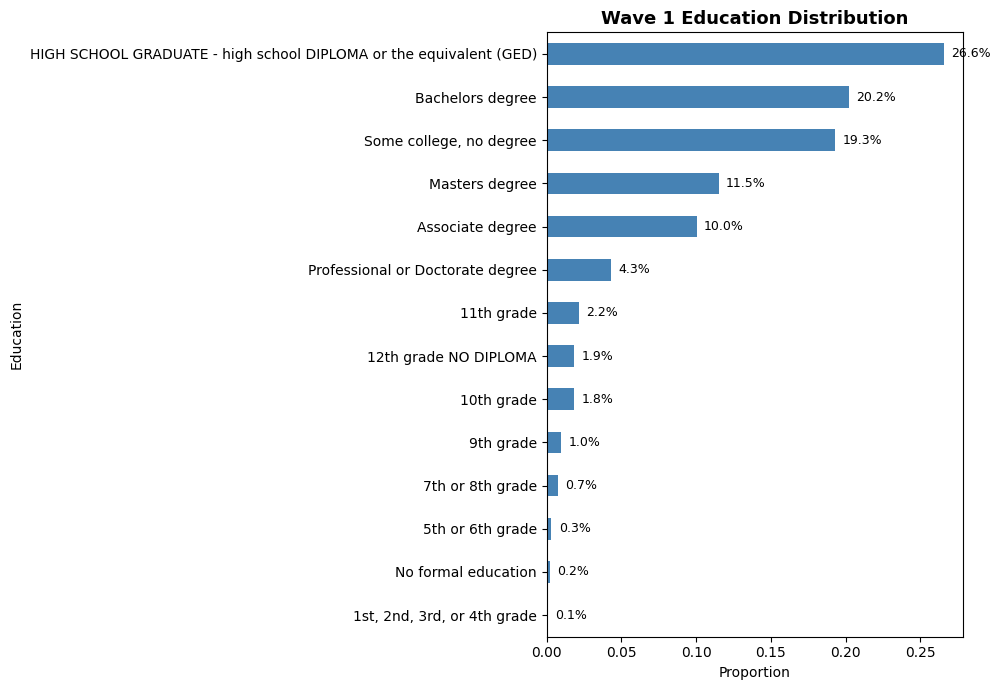

In [47]:
educ_dist = df["w1_ppeduc"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
educ_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 1 Education Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Education")

for i, val in enumerate(educ_dist.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

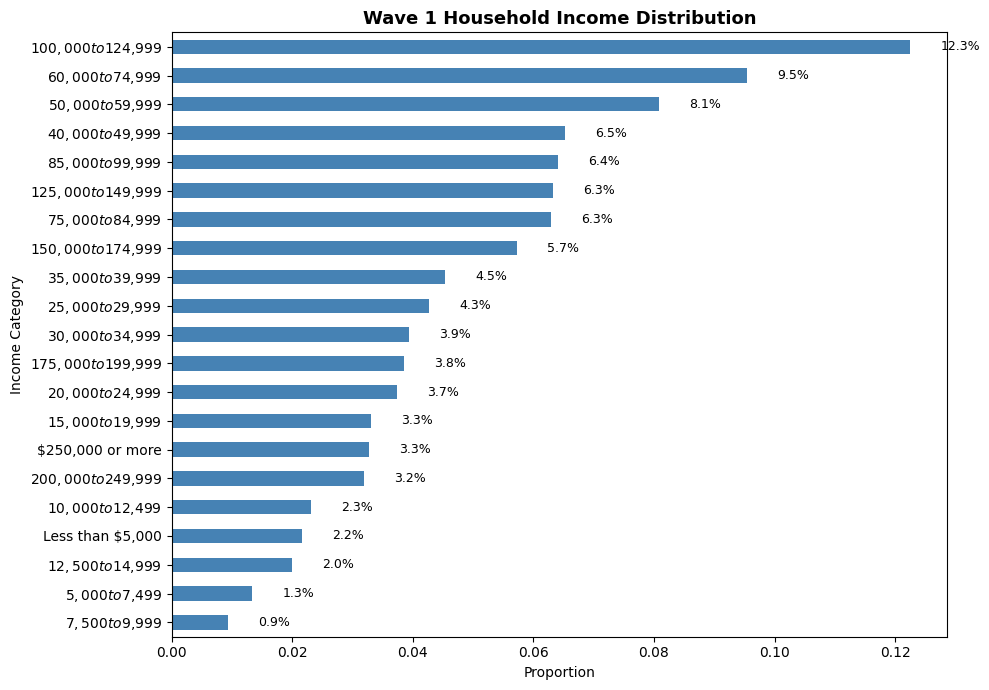

In [48]:
income_dist = df["w1_ppincimp"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
income_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 1 Household Income Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Income Category")

for i, val in enumerate(income_dist.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

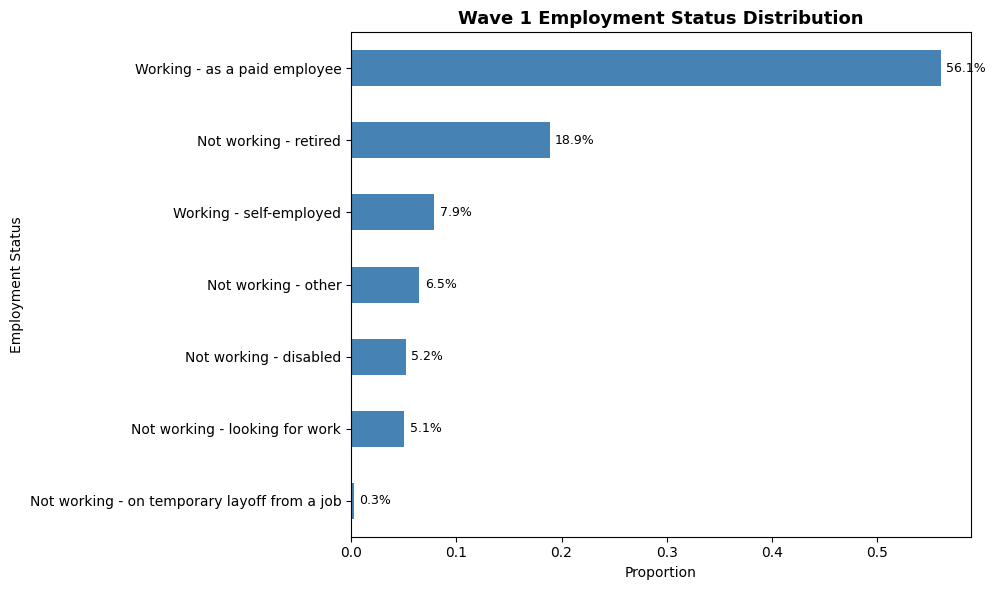

In [49]:
employment_dist = df["w1_ppwork"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
employment_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 1 Employment Status Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Employment Status")

for i, val in enumerate(employment_dist.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

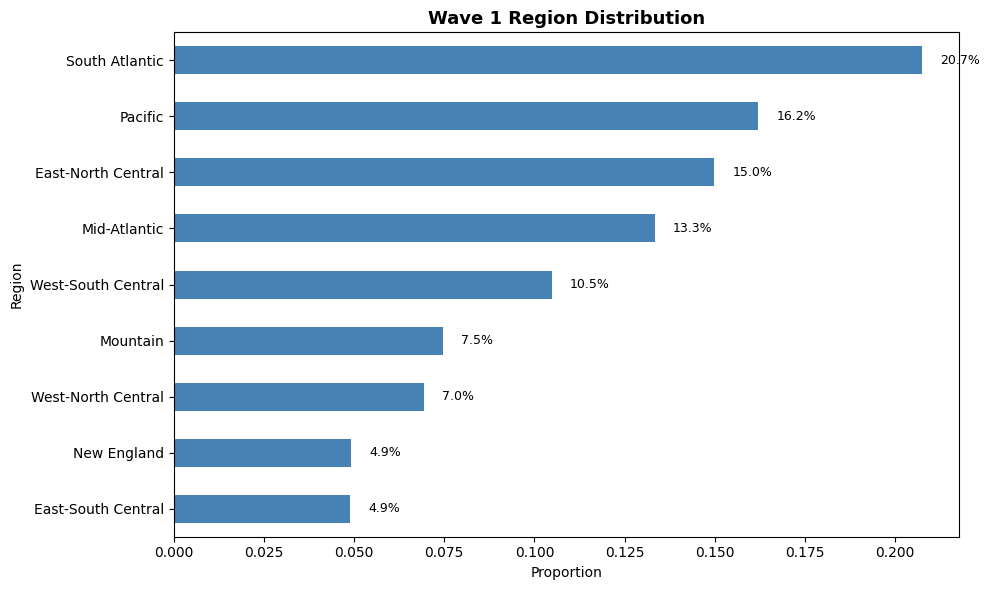

In [50]:
region_dist = df["w1_ppreg9"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
region_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 1 Region Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Region")

for i, val in enumerate(region_dist.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation

The Wave 1 sample is demographically broad. Age spans a wide adult range, gender is close to balanced, and respondents vary meaningfully across race/ethnicity, education, income, employment, and region. These variables provide useful background controls for later clustering and modeling.

## B. Aggregated Relationship Structure (Wave 1)

This section summarizes respondents’ baseline relationship situation in 2017.

Included:
- partnership status
- marital status
- cohabitation
- same-sex couple status
- relationship quality
- relationship duration

In [51]:
duration_num = safe_numeric(df["w1_relate_duration_in2017_years"])

relationship_summary = pd.DataFrame({
    "metric": [
        "active_relationships_wave1",
        "mean_relationship_duration_years",
        "median_relationship_duration_years",
        "married_count",
        "partnered_not_married_count",
        "cohabiting_yes_count",
        "same_sex_couple_count",
        "excellent_quality_count",
        "good_quality_count"
    ],
    "value": [
        (df["w1_partnership_status"].astype(str).isin(["married", "partnered, not married"])).sum(),
        round(duration_num.mean(), 2),
        round(duration_num.median(), 2),
        (df["w1_partnership_status"].astype(str) == "married").sum(),
        (df["w1_partnership_status"].astype(str) == "partnered, not married").sum(),
        (df["w1_q19"].astype(str) == "Yes").sum(),
        (df["w1_same_sex_couple"].astype(str) == "same_sex_couple").sum(),
        (df["w1_q34"].astype(str) == "Excellent").sum(),
        (df["w1_q34"].astype(str) == "Good").sum()
    ]
})

relationship_summary

,metric,value
0,active_relationships_wave1,2862.00
1,mean_relationship_duration_years,21.55
2,median_relationship_duration_years,18.08
3,married_count,2085.00
4,partnered_not_married_count,777.00
5,cohabiting_yes_count,2387.00
6,same_sex_couple_count,308.00
7,excellent_quality_count,1706.00
8,good_quality_count,884.00


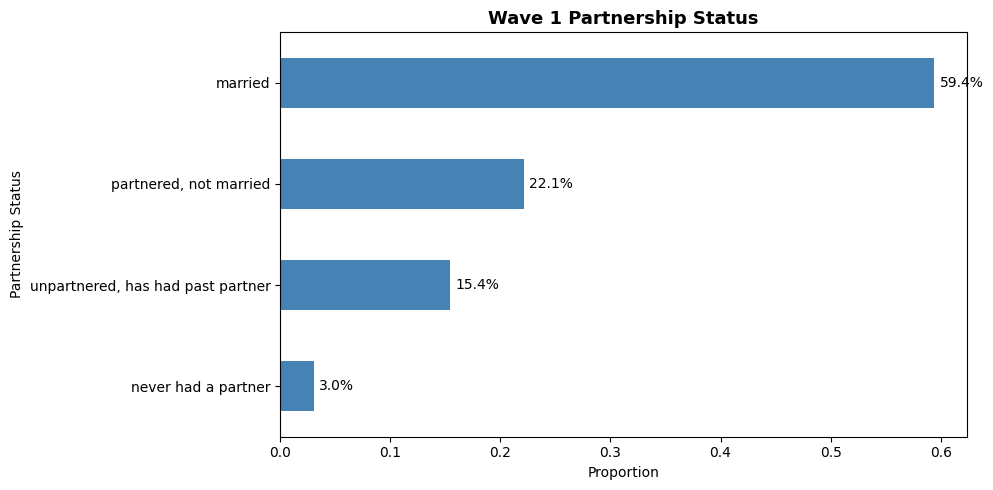

In [52]:
partnership_dist = df["w1_partnership_status"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
partnership_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 1 Partnership Status", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Partnership Status")

for i, val in enumerate(partnership_dist.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center")

plt.tight_layout()
plt.show()

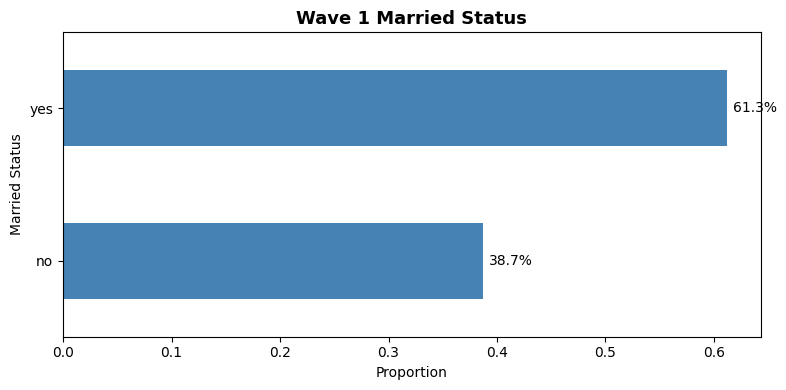

In [53]:
married_dist = df["w1_married"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
married_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 1 Married Status", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Married Status")

for i, val in enumerate(married_dist.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center")

plt.tight_layout()
plt.show()

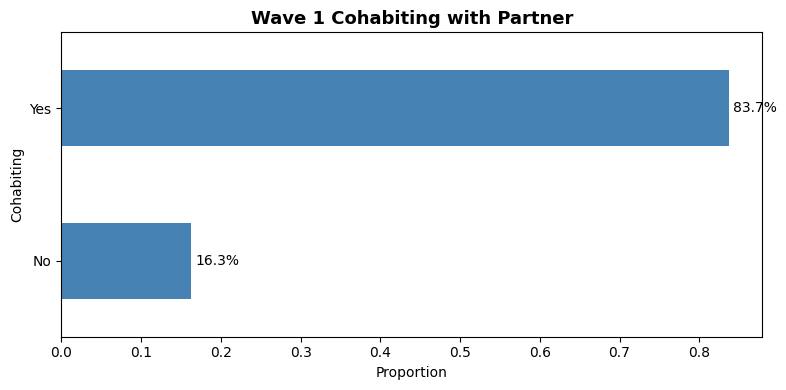

In [54]:
cohab_dist = df["w1_q19"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
cohab_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 1 Cohabiting with Partner", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Cohabiting")

for i, val in enumerate(cohab_dist.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center")

plt.tight_layout()
plt.show()

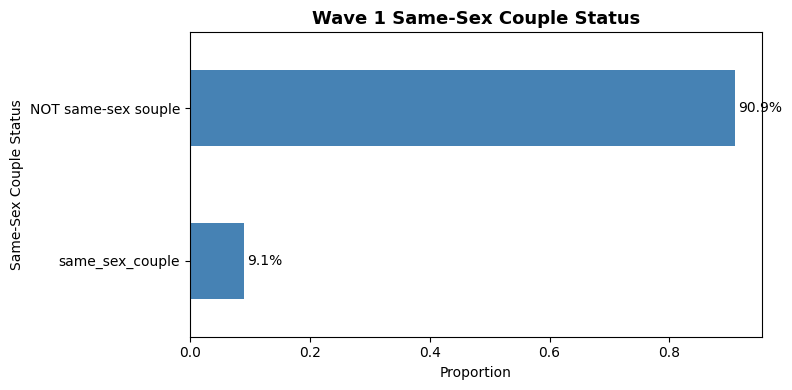

In [55]:
same_sex_dist = df["w1_same_sex_couple"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
same_sex_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 1 Same-Sex Couple Status", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Same-Sex Couple Status")

for i, val in enumerate(same_sex_dist.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center")

plt.tight_layout()
plt.show()

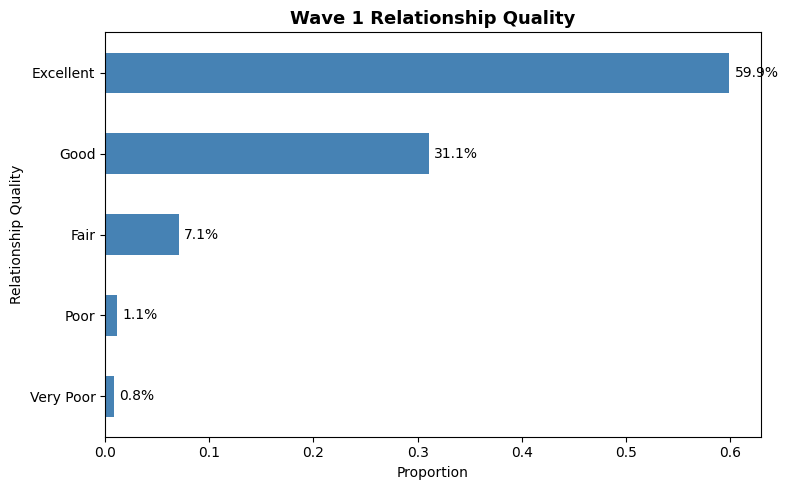

In [56]:
quality_order = ["Very Poor", "Poor", "Fair", "Good", "Excellent"]
quality_dist = (
    df["w1_q34"].astype(str)
    .value_counts(normalize=True)
    .reindex(quality_order)
)

fig, ax = plt.subplots(figsize=(8, 5))
quality_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 1 Relationship Quality", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Relationship Quality")

for i, val in enumerate(quality_dist.values):
    if pd.notna(val):
        ax.text(val + 0.005, i, f"{val:.1%}", va="center")

plt.tight_layout()
plt.show()

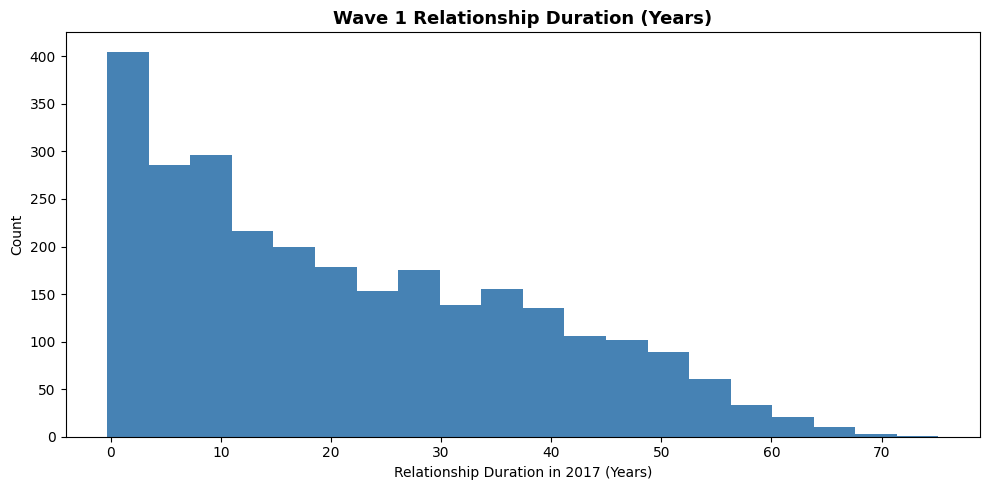

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))
duration_num.dropna().plot.hist(bins=20, ax=ax, color=PALETTE)

ax.set_title("Wave 1 Relationship Duration (Years)", fontsize=13, fontweight="bold")
ax.set_xlabel("Relationship Duration in 2017 (Years)")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Interpretation

Most respondents relevant to the project are in active relationships in Wave 1, with marriage being the largest category. Cohabitation is also common. Relationship quality is concentrated in “Good” and “Excellent,” suggesting a relatively strong baseline relationship profile for much of the sample.

## C. Aggregated “How Couples Met” (Wave 1)

This section summarizes the `w1_q24_*` family of variables, which record different pathways through which couples met.

Because these are multiple yes/no pathway indicators, they are aggregated together and visualized in one chart.

In [58]:
how_met_cols = [
    c
    for c in df.columns
    if c.startswith("w1_q24_")
    and c != "w1_q24_length"
    and "summary" not in c
    and "test" not in c
]

how_met_cols

['w1_q24_R_cowork',
 'w1_q24_R_friend',
 'w1_q24_R_family',
 'w1_q24_R_sig_other',
 'w1_q24_R_neighbor',
 'w1_q24_P_cowork',
 'w1_q24_P_friend',
 'w1_q24_P_family',
 'w1_q24_P_sig_other',
 'w1_q24_P_neighbor',
 'w1_q24_I_cowork',
 'w1_q24_I_friend',
 'w1_q24_I_family',
 'w1_q24_I_sig_other',
 'w1_q24_I_neighbor',
 'w1_q24_school',
 'w1_q24_college',
 'w1_q24_mil',
 'w1_q24_church',
 'w1_q24_vol_org',
 'w1_q24_customer',
 'w1_q24_bar_restaurant',
 'w1_q24_party',
 'w1_q24_internet_other',
 'w1_q24_internet_dating',
 'w1_q24_internet_soc_network',
 'w1_q24_internet_game',
 'w1_q24_internet_chat',
 'w1_q24_internet_org',
 'w1_q24_public',
 'w1_q24_blind_date',
 'w1_q24_vacation',
 'w1_q24_singles_serve_nonint',
 'w1_q24_business_trip',
 'w1_q24_work_neighbors',
 'w1_q24_met_online',
 'w1_q24_met_through_family',
 'w1_q24_met_through_friend',
 'w1_q24_met_through_as_nghbrs',
 'w1_q24_met_as_through_cowork',
 'w1_q24_metonline_no_phone_apps']

In [68]:
def yes_rate_mixed(series):
    s = series.copy()

    # Try numeric interpretation first
    numeric = pd.to_numeric(s, errors="coerce")
    if numeric.notna().sum() > 0:
        uniq = set(numeric.dropna().unique())
        if uniq.issubset({0, 1}):
            return numeric.mean()

    # Fallback to yes/no strings
    s_str = s.astype(str).str.strip().str.lower()
    valid_mask = s_str.isin(["yes", "no"])
    if valid_mask.sum() == 0:
        return np.nan

    return s_str[valid_mask].eq("yes").mean()

In [69]:
how_met_summary = (
    df[how_met_cols]
    .apply(yes_rate_mixed)
    .sort_values(ascending=False)
    .reset_index()
)

how_met_summary.columns = ["meeting_pathway", "proportion_yes"]

how_met_summary["meeting_pathway"] = (
    how_met_summary["meeting_pathway"]
    .str.replace("w1_q24_", "", regex=False)
)

how_met_summary

,meeting_pathway,proportion_yes
0,met_through_friend,0.281639
1,R_friend,0.229742
2,P_friend,0.221244
3,bar_restaurant,0.197876
4,met_as_through_cowork,0.165706
5,R_cowork,0.157208
6,P_cowork,0.152352
7,met_through_family,0.136874
8,met_online,0.118444
9,school,0.108649


In [70]:
how_met_summary[how_met_summary["proportion_yes"].isna()]

,meeting_pathway,proportion_yes


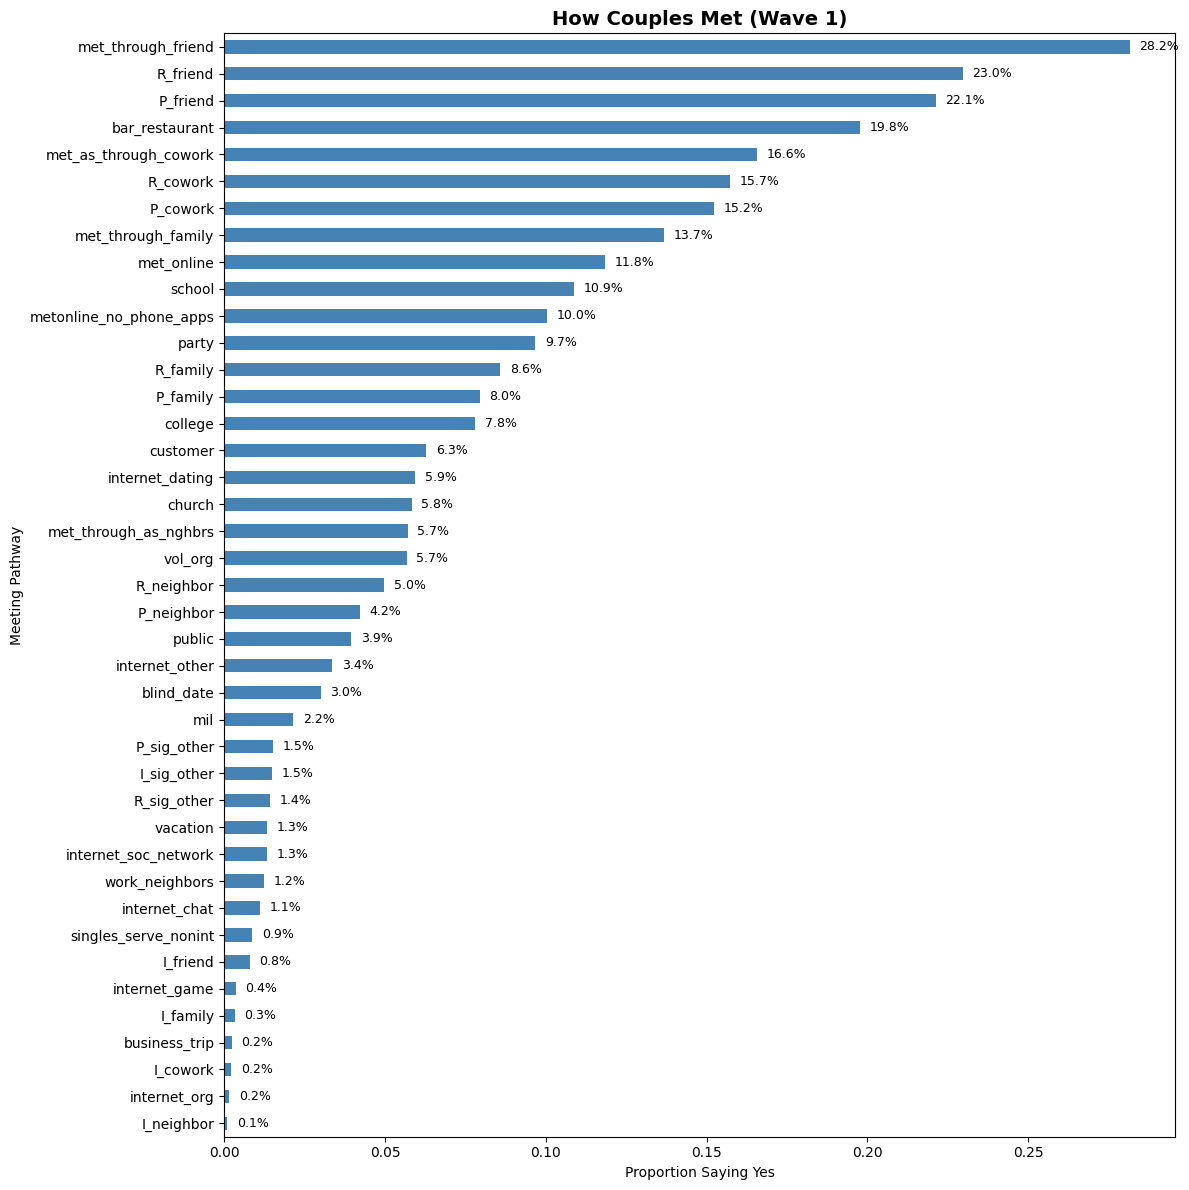

In [71]:
plot_df = how_met_summary.dropna().copy()

fig, ax = plt.subplots(figsize=(12, 12))

plot_df.sort_values("proportion_yes").plot.barh(
    x="meeting_pathway",
    y="proportion_yes",
    ax=ax,
    color=PALETTE,
    legend=False
)

ax.set_title("How Couples Met (Wave 1)", fontsize=14, fontweight="bold")
ax.set_xlabel("Proportion Saying Yes")
ax.set_ylabel("Meeting Pathway")

for i, val in enumerate(plot_df.sort_values("proportion_yes")["proportion_yes"].values):
    ax.text(val + 0.003, i, f"{val:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation

The `w1_q24_*` family shows that couples met through many different pathways. This provides a richer picture than a simple online/offline split and supports using meeting context as an important feature later in the project.

### Note on interpretation

The `w1_q24_*` family contains a mix of high-level summary pathways and more detailed component indicators, and the public translated file mixes storage formats across these variables. This chart is useful for exploratory review, but a later cleaned version should collapse overlapping categories for presentation and modeling.

## D. Aggregated Wave 3 Outcome Candidates

This section summarizes the later-wave variables that may be used to describe or construct relationship outcomes by 2022.

Included:
- Wave 3 participation
- partner type
- relationship-end categories

In [72]:
wave3_summary = pd.DataFrame({
    "metric": [
        "surveyed_wave3",
        "not_surveyed_wave3",
        "married_wave3",
        "unpartnered_wave3",
        "unmarried_partnership_wave3",
        "reported_breakup",
        "reported_divorce",
        "partner_died"
    ],
    "value": [
        (df["w3_surveyed"].astype(str) == "yes").sum(),
        (df["w3_surveyed"].astype(str) == "no").sum(),
        (df["w3_partner_type"].astype(str) == "married").sum(),
        (df["w3_partner_type"].astype(str) == "unpartnered").sum(),
        (df["w3_partner_type"].astype(str) == "in unmarried partnership").sum(),
        (df["w3_relationship_end_combo"].astype(str) == "Separated/ Broke up").sum(),
        (df["w3_relationship_end_combo"].astype(str) == "Got Divorced").sum(),
        (df["w3_relationship_end_combo"].astype(str) == "Partner died").sum()
    ]
})

wave3_summary

,metric,value
0,surveyed_wave3,1722
1,not_surveyed_wave3,1788
2,married_wave3,1061
3,unpartnered_wave3,385
4,unmarried_partnership_wave3,276
5,reported_breakup,62
6,reported_divorce,10
7,partner_died,27


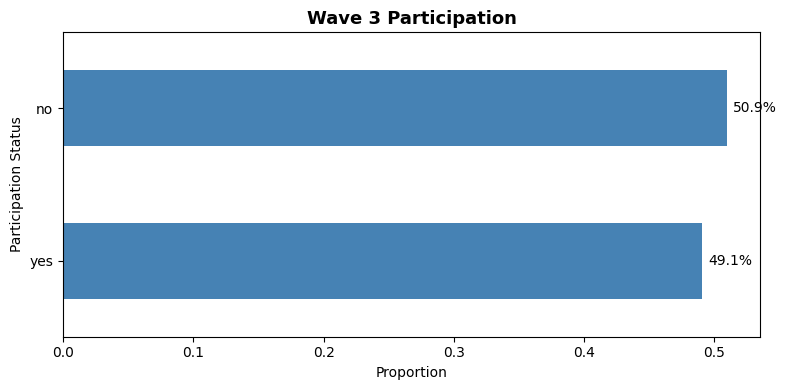

In [73]:
wave3_participation = df["w3_surveyed"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
wave3_participation.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 3 Participation", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Participation Status")

for i, val in enumerate(wave3_participation.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center")

plt.tight_layout()
plt.show()

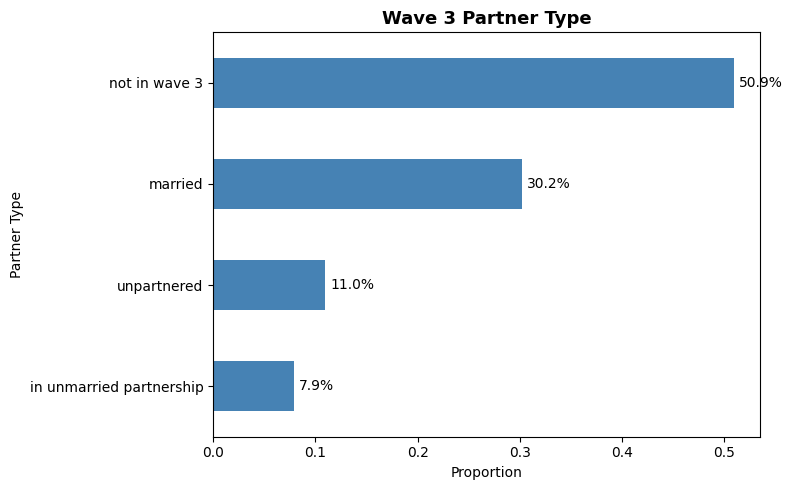

In [74]:
w3_partner_dist = df["w3_partner_type"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
w3_partner_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 3 Partner Type", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Partner Type")

for i, val in enumerate(w3_partner_dist.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center")

plt.tight_layout()
plt.show()

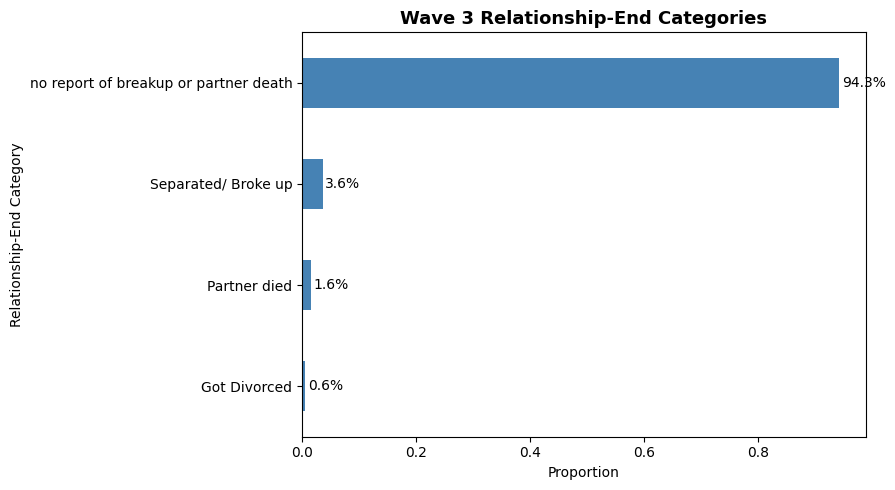

In [75]:
w3_end_dist = df["w3_relationship_end_combo"].astype(str).value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
w3_end_dist.plot.barh(ax=ax, color=PALETTE)

ax.set_title("Wave 3 Relationship-End Categories", fontsize=13, fontweight="bold")
ax.set_xlabel("Proportion")
ax.set_ylabel("Relationship-End Category")

for i, val in enumerate(w3_end_dist.values):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center")

plt.tight_layout()
plt.show()

### Interpretation

Wave 3 provides useful later relationship information, including partner status and relationship-end categories. At the same time, the large number of respondents not observed in Wave 3 highlights the importance of discussing attrition and using the appropriate later-wave weights in downstream analysis.

# Final EDA Takeaways

1. The HCMST dataset is a wide-format three-wave panel with 3510 original respondents.
2. The sample is demographically broad and varied enough for meaningful segmentation.
3. Most relevant Wave 1 respondents are in active relationships, with many reporting strong baseline relationship quality.
4. Couples met through multiple pathways, which supports a richer analysis than a simple online/offline split.
5. Wave 3 provides later relationship outcomes, but attrition is substantial and must be addressed carefully.

These exploratory findings justify the next steps:
- create a cleaned Wave 1 relationship sample
- prepare a clustering-ready dataset
- construct a later relationship outcome for modeling

In [76]:
demographics_summary.to_csv(OUTPUT_TABLES / "wave1_demographics_summary.csv", index=False)
relationship_summary.to_csv(OUTPUT_TABLES / "wave1_relationship_summary.csv", index=False)
how_met_summary.to_csv(OUTPUT_TABLES / "wave1_how_couples_met_summary.csv", index=False)
wave3_summary.to_csv(OUTPUT_TABLES / "wave3_outcome_candidates_summary.csv", index=False)